# ERA5 Heavy Precipitation Prediction

## Load ERA5 Data

In [2]:
import sys
import xarray as xr
import matplotlib.pyplot as plt

sys.path.append("..")

from src.data.load_era5 import load_era5, convert_longitude, subset_area

# Load all three datasets
ds = load_era5("../data/raw/era5_sample_autumn2020")
ds_pressure = load_era5("../data/raw/era5_pressure_sample_autumn2020.nc")
ds_cape = load_era5("../data/raw/era5_cape_sample_autumn2020.nc")

# Clean up wind pressure 
ds_pressure = convert_longitude(ds_pressure)
ds_pressure = subset_area(ds_pressure, north=60, south=48, west=-10, east=2)

# Clean up cape
ds_cape = convert_longitude(ds_cape)
ds_cape = subset_area(ds_cape, north=60, south=48, west=-10, east=2)

# Merge everything into one dataset
ds_merged = xr.merge([ds, ds_pressure, ds_cape]).sortby("pressure_level", ascending=False)
print(ds_merged)

/home/alf_walks/projects/python/HPCWeatherPredictionPipeline/notebooks/../src/data/load_era5.py:9: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ds = xr.open_mfdataset(files, combine="by_coords")
/home/alf_walks/projects/python/HPCWeatherPredictionPipeline/notebooks/../src/data/load_era5.py:9: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitl

<xarray.Dataset> Size: 178MB
Dimensions:         (valid_time: 488, latitude: 49, longitude: 49,
                     pressure_level: 8)
Coordinates:
  * valid_time      (valid_time) datetime64[ns] 4kB 2020-09-01 ... 2020-12-31...
    expver          (valid_time) <U4 8kB '0001' '0001' '0001' ... '0001' '0001'
  * latitude        (latitude) float64 392B 60.0 59.75 59.5 ... 48.5 48.25 48.0
  * longitude       (longitude) float64 392B -10.0 -9.75 -9.5 ... 1.5 1.75 2.0
  * pressure_level  (pressure_level) float64 64B 1e+03 925.0 ... 400.0 300.0
    number          int64 8B 0
Data variables:
    u10             (valid_time, latitude, longitude) float32 5MB dask.array<chunksize=(488, 49, 49), meta=np.ndarray>
    v10             (valid_time, latitude, longitude) float32 5MB dask.array<chunksize=(488, 49, 49), meta=np.ndarray>
    d2m             (valid_time, latitude, longitude) float32 5MB dask.array<chunksize=(488, 49, 49), meta=np.ndarray>
    t2m             (valid_time, latitude, longitu

/tmp/ipykernel_19415/719615568.py:23: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ds_merged = xr.merge([ds, ds_pressure, ds_cape]).sortby("pressure_level", ascending=False)
/tmp/ipykernel_19415/719615568.py:23: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ds_merged = xr.merge([ds, ds_pressure, ds_cape]).sortby("pressure_level", asc

## Calcuate wind shear

In [5]:
import sys
sys.path.append("..")
from src.features.meteorology import compute_shear_features

# compute all shear features
shear_features = compute_shear_features(ds_merged)

## Calculate Convective Available Potential Energy (CAPE)

In [ ]:
#
# 
# OPTIONAL CELL (not sure it is valid after scaling)
#
#
#Used for showing improvement on time taken with dask processes from sequential

import time
import numpy as np
import dask
from dask import delayed
from src.features.meteorology import (
    compute_cape_sequential,
    compute_cape_for_timestep,
)

n_time = len(ds_merged['valid_time'])

start = time.time()
result_seq = compute_cape_sequential(ds_merged)
time_seq = time.time() - start

start = time.time()
results_processes = dask.compute(
    *[delayed(compute_cape_for_timestep)(ds_merged, t) for t in range(n_time)],
    scheduler='processes'
)
time_processes = time.time() - start
cape_processes = np.stack(results_processes, axis=-1)

# Correctness 
match_processes = np.allclose(result_seq.values, cape_processes, equal_nan=True)

# Summary table
print(f"{'Method':<30}{'Time (s)':<12}{'Speedup':<10}{'Matches seq?'}")
print(f"{'Sequential':<30}{time_seq:<12.2f}{'1.00x':<10}{'-'}")
print(f"{'Dask batched (processes)':<30}{time_processes:<12.2f}{time_seq/time_processes:<10.2f}{match_processes}")

Method                        Time (s)    Speedup   Matches seq?
Sequential                    200.25      1.00x     -
Dask batched (processes)      30.98       6.46      True


In [ ]:
from src.features.meteorology import compute_cape_dask_batched
xrCape = compute_cape_dask_batched(ds_merged.load())

/home/alf_walks/projects/python/HPCWeatherPredictionPipeline/.venv/lib/python3.12/site-packages/metpy/calc/thermo.py:1753: RuntimeWarning: invalid value encountered in log
  val = np.log(vapor_pressure / mpconsts.nounit.sat_pressure_0c)
/home/alf_walks/projects/python/HPCWeatherPredictionPipeline/.venv/lib/python3.12/site-packages/metpy/calc/thermo.py:1753: RuntimeWarning: invalid value encountered in log
  val = np.log(vapor_pressure / mpconsts.nounit.sat_pressure_0c)
/home/alf_walks/projects/python/HPCWeatherPredictionPipeline/.venv/lib/python3.12/site-packages/metpy/calc/thermo.py:1753: RuntimeWarning: invalid value encountered in log
  val = np.log(vapor_pressure / mpconsts.nounit.sat_pressure_0c)


<xarray.DataArray 'cape' (latitude: 49, longitude: 49, valid_time: 488)> Size: 9MB
array([[[0.00000000e+00, 5.32405276e+00, 1.04645983e+01, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 2.58067640e+00, 3.39498083e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 2.54329023e-02, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        ...,
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 2.25957002e+01, 1.57955291e+01],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 2.28728377e+01, 1.37937802e+01],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 2.41723877e+01, 9.79305120e+00]],

       [[0.00000000e+00, 6.39047150e+00, 1.39702329e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 3.87297222e+00, 0.00000000e+00, ...,


## Save CAPE calculation


In [4]:
xrCape.to_netcdf("../data/processed/cape_autumn2020.nc")

In [8]:
import xarray as xr

xrCape = xr.open_dataset("../data/processed/cape_autumn2020.nc")["cape"]

In [9]:
import numpy as np

print("NaN count:", np.isnan(xrCape.values).sum())
print("Min:", xrCape.min().values, "Max:", xrCape.max().values)

NaN count: 0
Min: -204.10477812310617 Max: 1489.001388993977


## Compute BRN and build features dataframe

In [10]:
from src.features.meteorology import compute_brn
from src.features.build_dataset import build_dataset

brn = compute_brn(xrCape, shear_features["bulk_shear_10m_500"])
brn_named = brn.rename("brn")

precip = ds_merged['tp']

dfFeatures = build_dataset(shear_features, xrCape, brn_named, precip)
print(dfFeatures)

print(dfFeatures.isna().sum())
print(dfFeatures['heavy_rain'].value_counts())

                 valid_time  latitude  longitude  bulk_shear_10m_850  \
0       2020-09-01 00:00:00      60.0     -10.00            6.373995   
1       2020-09-01 00:00:00      60.0      -9.75            6.559042   
2       2020-09-01 00:00:00      60.0      -9.50            6.347345   
3       2020-09-01 00:00:00      60.0      -9.25            5.656353   
4       2020-09-01 00:00:00      60.0      -9.00            5.026325   
...                     ...       ...        ...                 ...   
1171683 2020-12-31 18:00:00      48.0       1.00            3.659222   
1171684 2020-12-31 18:00:00      48.0       1.25            3.519162   
1171685 2020-12-31 18:00:00      48.0       1.50            3.337471   
1171686 2020-12-31 18:00:00      48.0       1.75            3.007433   
1171687 2020-12-31 18:00:00      48.0       2.00            2.954267   

         bulk_shear_850_500  bulk_shear_10m_500  dir_shear_10m_850  \
0                 13.830307           19.837769          12.97357

## Save Work

In [11]:
#Checkpoint (so can start from here when restarting kernel)
dfFeatures.to_csv("../data/processed/era5_features_autumn2020.csv", index=False)

In [3]:
import pandas as pd

# Load the features
dfFeatures = pd.read_csv("../data/processed/era5_features_autumn2020.csv")

# Check it loaded correctly
print(dfFeatures.head())
print(dfFeatures.shape)
print(dfFeatures.columns)

            valid_time  latitude  longitude  bulk_shear_10m_850  \
0  2020-09-01 00:00:00      60.0     -10.00            6.373995   
1  2020-09-01 00:00:00      60.0      -9.75            6.559043   
2  2020-09-01 00:00:00      60.0      -9.50            6.347345   
3  2020-09-01 00:00:00      60.0      -9.25            5.656353   
4  2020-09-01 00:00:00      60.0      -9.00            5.026325   

   bulk_shear_850_500  bulk_shear_10m_500  dir_shear_10m_850  \
0           13.830307           19.837769          12.973572   
1           13.955747           20.094330          12.275879   
2           14.255699           20.088108           8.523041   
3           14.620013           19.552467           1.194733   
4           14.832037           18.785727          -5.844955   

   dir_shear_850_500  dir_shear_10m_500  cape  brn        tp  heavy_rain  
0          19.643234          32.616820   0.0  0.0  0.000013           0  
1          19.677536          31.953430   0.0  0.0  0.000034  

## Training data and classifier models

In [4]:
from src.models.train import makeTrainingData

feature_columns = ["bulk_shear_10m_850", "bulk_shear_850_500", "bulk_shear_10m_500", "dir_shear_10m_850", "dir_shear_850_500", "dir_shear_10m_500", "cape", "brn"]

X_train, X_test, y_train, y_test = makeTrainingData(dfFeatures, feature_columns)
print(y_train.value_counts())
print(y_test.value_counts())

heavy_rain
0    897401
1     39949
Name: count, dtype: int64
heavy_rain
0    224351
1      9987
Name: count, dtype: int64


In [5]:
from src.models.train import logModel
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd

model = logModel(X_train, y_train)
y_pred = model.predict(X_test)

print(pd.Series(y_pred).value_counts())

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

0    163020
1     71318
Name: count, dtype: int64
[[159422  64929]
 [  3598   6389]]
              precision    recall  f1-score   support

           0       0.98      0.71      0.82    224351
           1       0.09      0.64      0.16      9987

    accuracy                           0.71    234338
   macro avg       0.53      0.68      0.49    234338
weighted avg       0.94      0.71      0.79    234338



In [6]:
from sklearn.metrics import classification_report, confusion_matrix
from src.models.train import rfModel
from src.models.train import rfThresholdTune


rf_model = rfModel(X_train, y_train)

y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

results_df = rfThresholdTune(y_prob_rf, y_test)
print(results_df)


# Pick threshold with highest F1 score
best_threshold = results_df.loc[results_df["F1"].idxmax(), "Threshold"]

print("\nBest threshold:", best_threshold)

# evaluation using best threshold
y_pred_best = (y_prob_rf >= best_threshold).astype(int)

print(confusion_matrix(y_test, y_pred_best))
print(classification_report(y_test, y_pred_best))

   Threshold  Precision    Recall        F1
0       0.10   0.055479  0.981876  0.105024
1       0.15   0.063816  0.958947  0.119668
2       0.20   0.073086  0.925603  0.135475
3       0.25   0.083768  0.885251  0.153052
4       0.30   0.097298  0.839692  0.174389
5       0.35   0.113994  0.788825  0.199201
6       0.40   0.133266  0.731251  0.225446
7       0.45   0.155317  0.668669  0.252081
8       0.50   0.181650  0.601282  0.279010

Best threshold: 0.5
[[197298  27053]
 [  3982   6005]]
              precision    recall  f1-score   support

           0       0.98      0.88      0.93    224351
           1       0.18      0.60      0.28      9987

    accuracy                           0.87    234338
   macro avg       0.58      0.74      0.60    234338
weighted avg       0.95      0.87      0.90    234338



In [7]:
from src.models.train import xgbModel
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd

xgb_model = xgbModel(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

print(pd.Series(y_pred_xgb).value_counts())

print(confusion_matrix(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))

0    165272
1     69066
Name: count, dtype: int64
[[162394  61957]
 [  2878   7109]]
              precision    recall  f1-score   support

           0       0.98      0.72      0.83    224351
           1       0.10      0.71      0.18      9987

    accuracy                           0.72    234338
   macro avg       0.54      0.72      0.51    234338
weighted avg       0.95      0.72      0.81    234338



Logistic Regression
ROC-AUC: 0.7378475406111796
PR-AUC: 0.12532082221593327

Random Forest
ROC-AUC: 0.8419477919768626
PR-AUC: 0.3067894522627321

XGBoost
ROC-AUC: 0.798382373374773
PR-AUC: 0.2166036549443292


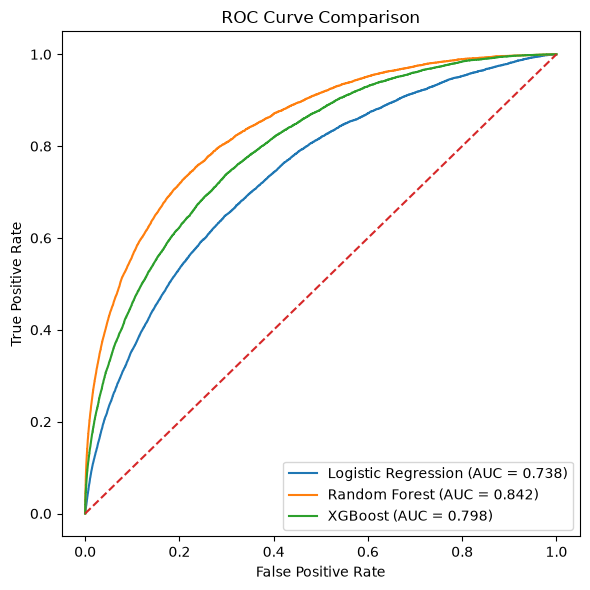

In [8]:
from sklearn.metrics import roc_auc_score, average_precision_score
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

log_probs = model.predict_proba(X_test)[:, 1]
rf_probs = rf_model.predict_proba(X_test)[:, 1]
xgb_probs = xgb_model.predict_proba(X_test)[:, 1]


print("Logistic Regression")
print("ROC-AUC:", roc_auc_score(y_test, log_probs))
print("PR-AUC:", average_precision_score(y_test, log_probs))

print("\nRandom Forest")
print("ROC-AUC:", roc_auc_score(y_test, rf_probs))
print("PR-AUC:", average_precision_score(y_test, rf_probs))

print("\nXGBoost")
print("ROC-AUC:", roc_auc_score(y_test, xgb_probs))
print("PR-AUC:", average_precision_score(y_test, xgb_probs))

# Logistic Regression
fpr_log, tpr_log, _ = roc_curve(y_test, log_probs)
auc_log = roc_auc_score(y_test, log_probs)

# Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_probs)
auc_rf = roc_auc_score(y_test, rf_probs)

# XGBoost
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_probs)
auc_xgb = roc_auc_score(y_test, xgb_probs)

plt.figure(figsize=(6,6))

plt.plot(fpr_log, tpr_log,
         label=f"Logistic Regression (AUC = {auc_log:.3f})")

plt.plot(fpr_rf, tpr_rf,
         label=f"Random Forest (AUC = {auc_rf:.3f})")

plt.plot(fpr_xgb, tpr_xgb,
         label=f"XGBoost (AUC = {auc_xgb:.3f})")

# Random classifier
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend(loc="lower right")

plt.tight_layout()
plt.show()

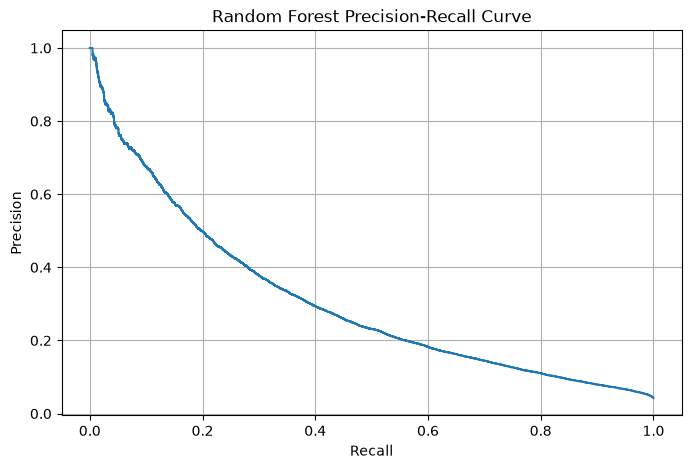

In [10]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precision, recall, thresholds = precision_recall_curve(
    y_test,
    y_prob_rf
)

plt.figure(figsize=(8, 5))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Random Forest Precision-Recall Curve")
plt.grid()
plt.show()

## RF feature importances

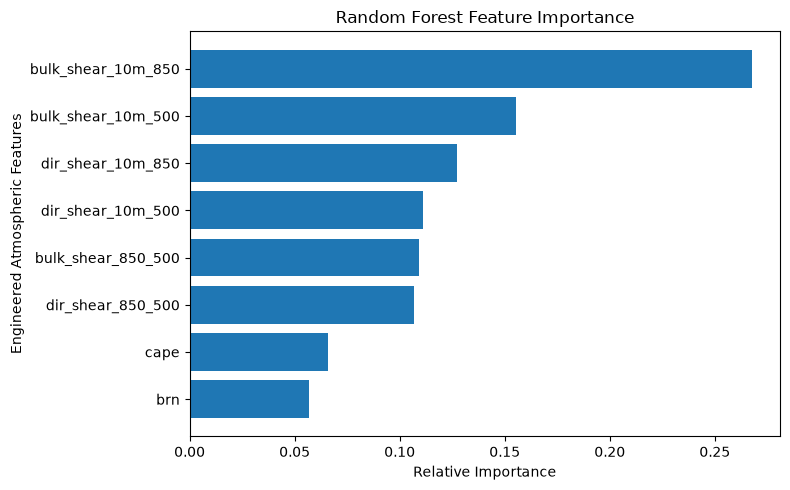

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

importances = rf_model.feature_importances_
results = (pd.DataFrame({"Feature": X_train.columns, "Importance": importances}).sort_values(by="Importance", ascending=False))

plt.figure(figsize=(8,5))
plt.barh(results["Feature"][::-1], results["Importance"][::-1])

plt.xlabel("Relative Importance")
plt.ylabel("Engineered Atmospheric Features")
plt.title("Random Forest Feature Importance")

plt.tight_layout()
plt.show()

In [12]:
import joblib
joblib.dump(rf_model, '../models/rf_autumn_2020.joblib')
joblib.dump(X_train.columns, '../models/heavy_rain_features.joblib')

['../models/heavy_rain_features.joblib']